Carregando os dados...
Classificação: 
              precision    recall  f1-score   support

      Empate       0.57      0.44      0.50         9
    O venceu       0.76      0.81      0.78        58
    Tem jogo       0.85      0.88      0.87       125
    X venceu       0.99      0.95      0.97       128

    accuracy                           0.88       320
   macro avg       0.79      0.77      0.78       320
weighted avg       0.88      0.88      0.88       320



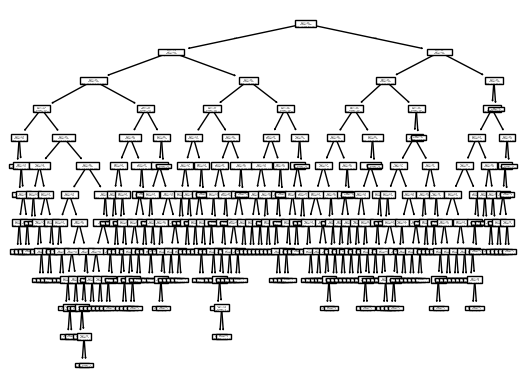

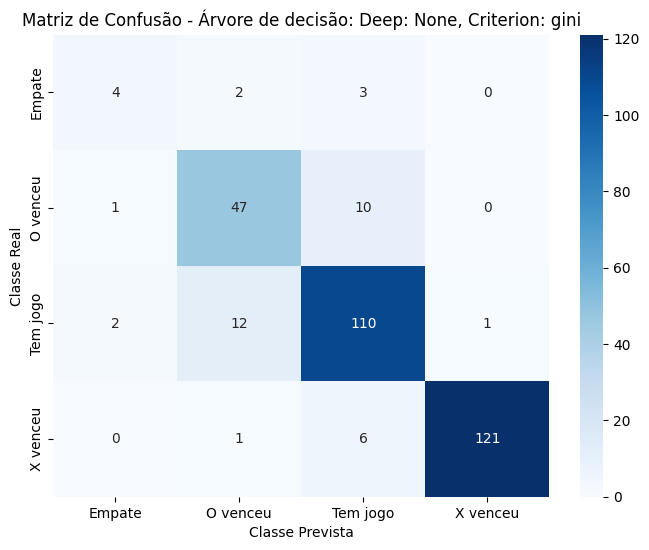

Sucesso! Modelo decision tree salvo em: ../../models/DecisionTree


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import csv
import joblib
import seaborn as sns
from sklearn.model_selection import train_test_split as train_test
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, confusion_matrix


# Carregando os dados a serem processador
print("Carregando os dados...")
df = pd.read_csv('../../data/processed/preprocessed_1.csv')
X = df.drop('classe', axis=1) #  O restante dos valores sem a classificação
y = df['classe'] # classificação

# Tranformação dos dados
le = LabelEncoder()
y_encoded = le.fit_transform(y)
x_train, x_test, y_train, y_test = train_test(X, y_encoded, test_size= 0.2, random_state=32)

# Definição árvore
max_deep = None      # Profundidade máxima
min_split = 2        # Quantas divisões são possíveis
criterion = "gini"   # 'gini', 'entropy', 'log_loss'
min_leaf = 2

decision_tree = DecisionTreeClassifier(
    max_depth=max_deep,
    min_samples_split=min_split,
    criterion=criterion,
    min_samples_leaf= min_leaf)

# Treinamento
decision_tree.fit(x_train, y_train)
y_prededicao = decision_tree.predict(x_test)

y_test_class = le.inverse_transform(y_test)
y_pred_class = le.inverse_transform(y_prededicao)

print("Classificação: ")
print(classification_report(y_test_class, y_pred_class))

# Mostrando árvore gerada
plot_tree(decision_tree)
plt.show()

print("\n")
# Matriz de Confusão

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_class, y_pred_class, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão - Árvore de decisão: Deep: {max_deep}, Criterion: {criterion}')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()


# Exportação para a Interface
import os
caminho_modelo = '../../models/DecisionTree'
os.makedirs(caminho_modelo, exist_ok=True)

joblib.dump(decision_tree, f'{caminho_modelo}/decision_tree.pkl')
joblib.dump(le, f'{caminho_modelo}/DecisionTree_label_encoder.pkl')
print(f"Sucesso! Modelo decision tree salvo em: {caminho_modelo}")


In [73]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
